In [1]:
import torch
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU available: True
GPU name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU memory: 102.0 GB


In [2]:
!pip install datasets tiktoken

## Step 1: Load the TinyStories Dataset
Loading 2.12M children's stories from HuggingFace. Each story is written for 3-4 year olds.

In [3]:
from datasets import load_dataset

# Load the TinyStories dataset from HuggingFace
# This may take a few minutes — we're downloading 2.12M stories
dataset = load_dataset("roneneldan/TinyStories")

print(f"Training stories: {len(dataset['train']):,}")
print(f"Validation stories: {len(dataset['validation']):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Training stories: 2,119,719
Validation stories: 21,990


## Exploring the Dataset
Let's look at what these stories actually look like and understand the data we're training on.

In [4]:
# Look at 3 sample stories
for i in range(5):
    story = dataset['train'][i]['text']
    word_count = len(story.split())
    print(f"--- Story {i+1} ({word_count} words) ---")
    print(story[:500])  # First 500 characters
    print()

--- Story 1 (134 words) ---
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them b

--- Story 2 (142 words) ---
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. Beep drove under the tree and watched the leaves fall on him. He laughed and beeped 

In [5]:
import numpy as np

# Calculate basic statistics about our dataset
word_counts = []
for i in range(min(10000, len(dataset['train']))):  # Sample 10K stories for speed
    story = dataset['train'][i]['text']
    word_counts.append(len(story.split()))

print(f"Average story length: {np.mean(word_counts):.0f} words")
print(f"Median story length: {np.median(word_counts):.0f} words")
print(f"Shortest story: {np.min(word_counts)} words")
print(f"Longest story: {np.max(word_counts)} words")

Average story length: 169 words
Median story length: 151 words
Shortest story: 43 words
Longest story: 878 words


## Step 2: Tokenize the Dataset
Converting all stories from text → token IDs using GPT-2's BPE tokenizer.
Token IDs are stored in .bin files on disk for efficient training.

Testing

In [6]:
import tiktoken
import numpy as np
import os

# Get the GPT-2 tokenizer
# This is a Byte Pair Encoding (BPE) tokenizer with 50,257 tokens in its vocabulary
enc = tiktoken.get_encoding("gpt2")

# Let's see how tokenization works on a sample sentence
sample = "Once upon a time there was a little girl"
tokens = enc.encode(sample)
print(f"Text: {sample}")
print(f"Tokens: {tokens}")
print(f"Number of tokens: {len(tokens)}")
print(f"Vocabulary size: {enc.n_vocab}")

# Decode back to verify
decoded = enc.decode(tokens)
print(f"Decoded back: {decoded}")

Text: Once upon a time there was a little girl
Tokens: [7454, 2402, 257, 640, 612, 373, 257, 1310, 2576]
Number of tokens: 9
Vocabulary size: 50257
Decoded back: Once upon a time there was a little girl


Tokenize the Full Dataset

In [7]:
from datasets import load_dataset
import numpy as np
import tiktoken
import os
from tqdm import tqdm

enc = tiktoken.get_encoding("gpt2")

def tokenize_story(story):
    """Convert a single story to token IDs."""
    ids = enc.encode_ordinary(story['text'])
    ids.append(enc.eot_token)  # Add end-of-text token
    return {'ids': ids, 'len': len(ids)}

# Tokenize all stories (this applies the function to every row)
# num_proc uses multiple CPU cores to speed this up
tokenized = dataset.map(
    tokenize_story,
    remove_columns=['text'],
    desc="Tokenizing stories",
    num_proc=4,
)

# Count total tokens
for split, dset in tokenized.items():
    total_tokens = np.sum(dset['len'])
    print(f"{split}: {total_tokens:,} total tokens")

Tokenizing stories (num_proc=4):   0%|          | 0/2119719 [00:00<?, ? examples/s]

Tokenizing stories (num_proc=4):   0%|          | 0/21990 [00:00<?, ? examples/s]

train: 473,992,236 total tokens
validation: 4,765,918 total tokens


Now save to .bin files on disk:

In [8]:
# Save all token IDs to .bin files
# Using memory-mapped arrays so we don't overload RAM

for split, dset in tokenized.items():
    # Calculate total number of tokens in this split
    total_len = np.sum(dset['len'])
    print(f"\nSaving {split} split: {total_len:,} tokens")

    # Create a memory-mapped file on disk
    filename = f'{split}.bin'
    arr = np.memmap(filename, dtype=np.uint16, mode='w+', shape=(total_len,))

    # Write token IDs in batches (1024 batches for efficiency)
    total_batches = min(1024, len(dset))
    idx = 0

    for batch_idx in tqdm(range(total_batches), desc=f'Writing {split}.bin'):
        # Get a batch of tokenized stories
        batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True)

        # Concatenate all token IDs in this batch
        arr_batch = np.concatenate(batch['ids'])

        # Write to the memory-mapped array
        arr[idx : idx + len(arr_batch)] = arr_batch
        idx += len(arr_batch)

    # Flush to disk (actually save the file)
    arr.flush()
    print(f"Saved {filename} ({os.path.getsize(filename) / 1e6:.1f} MB)")


Saving train split: 473,992,236 tokens


Writing train.bin: 100%|██████████| 1024/1024 [04:50<00:00,  3.52it/s]


Saved train.bin (948.0 MB)

Saving validation split: 4,765,918 tokens


Writing validation.bin: 100%|██████████| 1024/1024 [00:03<00:00, 280.56it/s]

Saved validation.bin (9.5 MB)


What just happened:

Every story was converted to a list of token IDs
An end-of-text token was added after each story (so the model knows where one story ends and the next begins)
All token IDs were concatenated into one giant array
That array was saved to disk as train.bin and validation.bin
We used memory-mapped arrays (np.memmap) so we don't run out of RAM

Why .bin files? As explained in the video — storing on disk instead of RAM prevents memory overload. With 2M+ stories and ~120M tokens, holding everything in RAM would be expensive. Memory-mapped files let us read from disk as if it were RAM, but without actually loading it all at once.
Issue #2 is now complete. You have train.bin and validation.bin with all your token IDs.

## Step 3: Create the Batch Pipeline
Building the function that feeds training data to the model in batches.
Each batch contains input sequences (X) and target sequences (Y, shifted right by 1).

In [9]:
import torch

# ============================================
# MODEL & TRAINING CONFIGURATION
# ============================================
# These are the key decisions that define our model.
# See ARCHITECTURE.md for why we chose each value.

# Model architecture
vocab_size = 50257     # GPT-2 BPE tokenizer vocabulary size
n_embd = 384           # Embedding dimension (768 for GPT-2, we use 384 to keep model small)
n_head = 6             # Number of attention heads per transformer block
n_layer = 6            # Number of transformer blocks
block_size = 128       # Context window — max tokens the model sees at once
dropout = 0.1          # Dropout rate for regularization

# Training
batch_size = 32        # Number of sequences processed in parallel
max_iters = 20000      # Total training iterations
eval_interval = 500    # How often to check training/validation loss
learning_rate = 1e-4   # How big of a step to take when updating weights
warmup_steps = 100     # Gradually increase learning rate at the start
min_lr = 1e-5          # Minimum learning rate after decay
grad_accum_steps = 32  # Accumulate gradients over this many steps before updating
eval_iters = 200       # Number of batches to average when estimating loss

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


Now the get_batch function:

In [10]:
# Load our tokenized data from disk
train_data = np.memmap('train.bin', dtype=np.uint16, mode='r')
val_data = np.memmap('validation.bin', dtype=np.uint16, mode='r')

print(f"Training tokens: {len(train_data):,}")
print(f"Validation tokens: {len(val_data):,}")

def get_batch(split):
    """
    Get a random batch of input (X) and target (Y) sequences.

    How it works:
    1. Pick `batch_size` random starting positions in the data
    2. For each position, grab `block_size` consecutive tokens → that's X
    3. Shift X right by 1 → that's Y (the target the model should predict)

    Example (block_size=4):
      Data: [1, 11, 15, 24, 11, 7, 3, ...]
      If we start at position 0:
        X = [1, 11, 15, 24]
        Y = [11, 15, 24, 11]   ← shifted right by 1

      This gives us 4 prediction tasks:
        Input [1] → predict 11
        Input [1, 11] → predict 15
        Input [1, 11, 15] → predict 24
        Input [1, 11, 15, 24] → predict 11
    """
    data = train_data if split == 'train' else val_data

    # Pick random starting positions
    ix = torch.randint(len(data) - block_size, (batch_size,))

    # Create X (input) and Y (target) tensors
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])

    # Move to GPU with optimized memory transfer
    x = x.pin_memory().to(device, non_blocking=True)
    y = y.pin_memory().to(device, non_blocking=True)

    return x, y

# Test it
x, y = get_batch('train')
print(f"\nBatch shapes:")
print(f"  X (input):  {x.shape}  → {batch_size} sequences of {block_size} tokens each")
print(f"  Y (target): {y.shape}  → same shape, shifted right by 1")
print(f"\nFirst sequence X: {x[0][:10].tolist()}...")
print(f"First sequence Y: {y[0][:10].tolist()}...")
print(f"Notice Y is X shifted by 1: X[1:] == Y[:-1]")

Training tokens: 473,992,236
Validation tokens: 4,765,918

Batch shapes:
  X (input):  torch.Size([32, 128])  → 32 sequences of 128 tokens each
  Y (target): torch.Size([32, 128])  → same shape, shifted right by 1

First sequence X: [19859, 13, 5045, 290, 3409, 547, 12008, 379, 717, 11]...
First sequence Y: [13, 5045, 290, 3409, 547, 12008, 379, 717, 11, 475]...
Notice Y is X shifted by 1: X[1:] == Y[:-1]


What pin_memory and non_blocking do:

pin_memory() = locks the data in RAM so the GPU can grab it faster (like putting a package at the front door instead of in the basement)

non_blocking=True = the CPU doesn't wait around while data is being copied to the GPU — it starts preparing the next batch immediately

## Step 4: Define the Transformer Model Architecture
Building a GPT-2 style decoder-only transformer with ~15M parameters.
Components: token embeddings, positional embeddings, multi-head attention,
feed-forward networks, layer normalization, and residual connections.

Now the model code. This is one large code cell — I've added comments explaining every piece:

In [11]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import math

# ============================================
# LAYER NORMALIZATION
# ============================================
# Normalizes inputs to each layer so training is stable.
# Without this, values can explode or vanish during training.
# Used before attention and before feed-forward in each transformer block.

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)


# ============================================
# CAUSAL SELF-ATTENTION (Single Head)
# ============================================
# This is where the model learns which tokens are important to each other.
# "Causal" means each token can only look at tokens BEFORE it (not after).
# This makes sense because when generating text, you can't see the future.
#
# Multi-head attention runs multiple attention heads in parallel.
# Each head might learn different patterns:
#   - One head might learn grammar (subject-verb agreement)
#   - Another might learn meaning (nouns referring to the same thing)
#   - Another might learn narrative flow (what comes next in a story)

class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        assert n_embd % n_head == 0

        # Three linear projections: Query, Key, Value — all in one matrix for efficiency
        # Query = "what am I looking for?"
        # Key = "what do I contain?"
        # Value = "what information do I give?"
        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=False)

        # Output projection
        self.c_proj = nn.Linear(n_embd, n_embd, bias=False)

        # Regularization
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        self.n_head = n_head
        self.n_embd = n_embd

        # Causal mask — prevents looking at future tokens
        # Lower triangular matrix: position i can only attend to positions 0..i
        self.register_buffer("bias", torch.tril(torch.ones(block_size, block_size))
                                     .view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.size()  # Batch, Sequence length (Time), Embedding dim (Channels)

        # Calculate Query, Key, Value for all heads at once
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)

        # Reshape into multiple heads
        # (B, T, C) → (B, n_heads, T, head_size)
        head_size = C // self.n_head
        k = k.view(B, T, self.n_head, head_size).transpose(1, 2)
        q = q.view(B, T, self.n_head, head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, head_size).transpose(1, 2)

        # Attention scores: how much should each token attend to every other token?
        # Scale by sqrt(head_size) to prevent scores from getting too large
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(head_size))

        # Apply causal mask — set future positions to -infinity (which becomes 0 after softmax)
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))

        # Softmax converts scores to probabilities (0 to 1, sum to 1)
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        # Weighted sum of values based on attention scores
        y = att @ v

        # Reassemble all heads back together
        # (B, n_heads, T, head_size) → (B, T, C)
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        # Final projection
        y = self.resid_dropout(self.c_proj(y))
        return y


# ============================================
# FEED-FORWARD NETWORK
# ============================================
# A simple two-layer neural network applied to each token independently.
# Expands the dimension by 4x, applies a non-linearity (GELU), then compresses back.
# This is where the model "thinks" about each token after gathering context from attention.

class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.c_fc = nn.Linear(n_embd, 4 * n_embd, bias=False)    # Expand: 384 → 1536
        self.gelu = nn.GELU()                                       # Non-linear activation
        self.c_proj = nn.Linear(4 * n_embd, n_embd, bias=False)   # Compress: 1536 → 384
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


# ============================================
# TRANSFORMER BLOCK
# ============================================
# One complete transformer block = attention + feed-forward + residual connections.
# Our model has 6 of these stacked on top of each other.
#
# The flow inside one block:
#   1. Layer norm → Multi-head attention → Add residual (skip connection)
#   2. Layer norm → Feed-forward network → Add residual (skip connection)
#
# Residual connections (the "+ x" parts) are crucial:
#   They let gradients flow directly through the network during backpropagation,
#   preventing the "vanishing gradient" problem in deep networks.

class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln_1 = LayerNorm(n_embd)
        self.attn = CausalSelfAttention()
        self.ln_2 = LayerNorm(n_embd)
        self.mlp = FeedForward()

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))   # Attention + residual
        x = x + self.mlp(self.ln_2(x))     # Feed-forward + residual
        return x


# ============================================
# THE FULL GPT MODEL
# ============================================
# Assembles everything: embeddings → transformer blocks → output head.
#
# Flow:
#   Input token IDs [1, 11, 15, 24]
#     → Token embedding (look up 384-dim vector for each token)
#     → Positional embedding (add position information)
#     → 6 × Transformer blocks (attention + feed-forward)
#     → Layer norm
#     → Output head (project 384-dim → 50,257-dim = probability over all possible next tokens)
#     → Logits (unnormalized probabilities)

class GPT(nn.Module):
    def __init__(self):
        super().__init__()

        # Token embeddings: vocabulary_size × embedding_dim
        # Each of the 50,257 possible tokens gets a 384-dimensional vector
        self.token_embedding = nn.Embedding(vocab_size, n_embd)

        # Positional embeddings: context_window × embedding_dim
        # Encodes WHERE each token is in the sequence (position 0, 1, 2, ... 127)
        self.position_embedding = nn.Embedding(block_size, n_embd)

        # Dropout after embeddings
        self.drop = nn.Dropout(dropout)

        # Stack of transformer blocks
        self.blocks = nn.Sequential(*[TransformerBlock() for _ in range(n_layer)])

        # Final layer norm
        self.ln_f = LayerNorm(n_embd)

        # Output head: embedding_dim → vocabulary_size
        # Projects from 384 dimensions to 50,257 — one score per possible next token
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

        # Weight tying: share weights between token embedding and output head
        # This is a proven trick that reduces parameters and improves performance
        self.token_embedding.weight = self.lm_head.weight

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        """Initialize weights with small random values for stable training."""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        """
        Forward pass through the entire model.

        Args:
            idx: Input token IDs, shape (batch_size, sequence_length)
            targets: Target token IDs (for training), shape (batch_size, sequence_length)

        Returns:
            logits: Predicted scores for each token, shape (batch, sequence, vocab_size)
            loss: Cross-entropy loss (only if targets provided)
        """
        B, T = idx.size()

        # Create position indices [0, 1, 2, ..., T-1]
        pos = torch.arange(0, T, dtype=torch.long, device=device)

        # Get embeddings
        tok_emb = self.token_embedding(idx)      # (B, T, n_embd)
        pos_emb = self.position_embedding(pos)    # (T, n_embd)
        x = self.drop(tok_emb + pos_emb)          # Add token + position embeddings

        # Pass through all transformer blocks
        x = self.blocks(x)                         # (B, T, n_embd)

        # Final layer norm
        x = self.ln_f(x)                           # (B, T, n_embd)

        # Project to vocabulary size to get prediction scores
        logits = self.lm_head(x)                   # (B, T, vocab_size)

        # Calculate loss if we have targets
        loss = None
        if targets is not None:
            # Reshape for cross-entropy:
            # logits: (B*T, vocab_size) — model's prediction for every position
            # targets: (B*T) — the correct answer for every position
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.8, top_k=50):
        """
        Generate new tokens one at a time.

        This is the inference function — how the model creates stories.
        For each step:
          1. Feed current sequence to the model
          2. Get probability distribution over all possible next tokens
          3. Sample from that distribution (with temperature and top-k filtering)
          4. Append the sampled token to the sequence
          5. Repeat

        Args:
            idx: Starting token IDs, shape (1, sequence_length)
            max_new_tokens: How many tokens to generate
            temperature: Controls randomness (lower = more predictable, higher = more creative)
            top_k: Only consider the top K most likely tokens at each step
        """
        for _ in range(max_new_tokens):
            # Crop to the last block_size tokens (context window limit)
            idx_cond = idx[:, -block_size:]

            # Get predictions
            logits, _ = self(idx_cond)

            # Only look at the last token's predictions
            logits = logits[:, -1, :] / temperature

            # Top-k filtering: zero out everything except top K tokens
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')

            # Convert to probabilities
            probs = F.softmax(logits, dim=-1)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)

            # Append to sequence
            idx = torch.cat((idx, idx_next), dim=1)

        return idx


# ============================================
# CREATE THE MODEL
# ============================================

model = GPT()
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params / 1e6:.1f}M parameters")

Total parameters: 29,974,656
Trainable parameters: 29,974,656
Model size: ~30.0M parameters


You have a full transformer architecture with ~15M parameters.
Take a breath here — this is the most complex piece of the entire project. The model is built. Everything from here is about training it and using it.

## Step 5: Loss Estimation
A helper function that evaluates how well the model is doing on both training and validation data.

In [12]:
@torch.no_grad()
def estimate_loss():
    """
    Estimate the average loss on training and validation sets.

    We run the model on `eval_iters` random batches from each set
    and average the loss. This gives us a stable estimate
    (a single batch would be too noisy to judge progress).

    @torch.no_grad() tells PyTorch not to track gradients here —
    we're just measuring, not training. This saves memory and speed.
    """
    out = {}
    model.eval()  # Set model to evaluation mode (disables dropout)

    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()

    model.train()  # Set back to training mode
    return out

The loss function is built into the model's forward pass (the F.cross_entropy call), and estimate_loss() gives us a way to track progress.

## Step 6: Training Loop
The main training loop with production-level optimizations:
- Mixed precision (float16 for speed, float32 for stability)
- Gradient accumulation (simulate larger batch sizes)
- Learning rate warmup + cosine decay
- Model checkpointing (save the best model)

In [13]:
import time

# ============================================
# OPTIMIZER
# ============================================
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# ============================================
# LEARNING RATE SCHEDULE
# ============================================
def get_lr(it):
    """
    Learning rate schedule: warmup + cosine decay.

    - Warmup (first 100 steps): gradually increase LR from 0 to learning_rate
      Why? A large LR at the very start can destabilize randomly-initialized weights

    - Cosine decay (after warmup): smoothly decrease LR down to min_lr
      Why? As the model gets closer to a good solution, we want smaller updates
    """
    # Warmup phase
    if it < warmup_steps:
        return learning_rate * it / warmup_steps

    # After warmup: cosine decay
    decay_ratio = (it - warmup_steps) / (max_iters - warmup_steps)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (learning_rate - min_lr)

# ============================================
# MIXED PRECISION SETUP
# ============================================
# Automatic Mixed Precision (AMP) uses float16 for most operations
# (matrix multiplication, dropout) but keeps float32 for operations
# that need precision (softmax, loss calculation).
# This makes training ~2x faster on modern GPUs.
scaler = torch.amp.GradScaler('cuda')

# ============================================
# TRAINING LOOP
# ============================================
print("Starting training...")
print(f"Total iterations: {max_iters:,}")
print(f"Batch size: {batch_size}")
print(f"Gradient accumulation steps: {grad_accum_steps}")
print(f"Effective batch size: {batch_size * grad_accum_steps}")
print(f"Context window: {block_size} tokens")
print(f"Eval every {eval_interval} iterations")
print()

best_val_loss = float('inf')
train_losses = []
val_losses = []
start_time = time.time()

for iter_num in range(max_iters):

    # Update learning rate
    lr = get_lr(iter_num)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    # ---- Evaluate periodically ----
    if iter_num % eval_interval == 0 or iter_num == max_iters - 1:
        losses = estimate_loss()
        elapsed = time.time() - start_time
        print(f"Step {iter_num:>5d} | "
              f"train loss: {losses['train']:.4f} | "
              f"val loss: {losses['val']:.4f} | "
              f"lr: {lr:.6f} | "
              f"time: {elapsed:.0f}s")

        train_losses.append(losses['train'].item())
        val_losses.append(losses['val'].item())

        # Save best model
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), 'best_model.pt')
            print(f"  → New best model saved! (val loss: {best_val_loss:.4f})")

    # ---- Training step with gradient accumulation ----
    # Instead of updating weights every single batch, we accumulate
    # gradients over `grad_accum_steps` batches first.
    # This simulates a larger batch size without needing more GPU memory.

    optimizer.zero_grad(set_to_none=True)

    for micro_step in range(grad_accum_steps):
        X, Y = get_batch('train')

        # Mixed precision forward pass
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logits, loss = model(X, Y)
            loss = loss / grad_accum_steps  # Scale loss by accumulation steps

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()

    # Clip gradients to prevent explosion
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    # Update weights
    scaler.step(optimizer)
    scaler.update()

total_time = time.time() - start_time
print(f"\nTraining complete! Total time: {total_time/60:.1f} minutes")
print(f"Best validation loss: {best_val_loss:.4f}")

Starting training...
Total iterations: 20,000
Batch size: 32
Gradient accumulation steps: 32
Effective batch size: 1024
Context window: 128 tokens
Eval every 500 iterations

Step     0 | train loss: 10.9058 | val loss: 10.9063 | lr: 0.000000 | time: 4s
  → New best model saved! (val loss: 10.9063)
Step   500 | train loss: 3.1998 | val loss: 3.2137 | lr: 0.000100 | time: 200s
  → New best model saved! (val loss: 3.2137)
Step  1000 | train loss: 2.6295 | val loss: 2.6401 | lr: 0.000100 | time: 396s
  → New best model saved! (val loss: 2.6401)
Step  1500 | train loss: 2.3571 | val loss: 2.3605 | lr: 0.000099 | time: 592s
  → New best model saved! (val loss: 2.3605)
Step  2000 | train loss: 2.2007 | val loss: 2.2096 | lr: 0.000098 | time: 788s
  → New best model saved! (val loss: 2.2096)
Step  2500 | train loss: 2.1182 | val loss: 2.1096 | lr: 0.000097 | time: 984s
  → New best model saved! (val loss: 2.1096)
Step  3000 | train loss: 2.0488 | val loss: 2.0432 | lr: 0.000095 | time: 1180s
 

Plot Training Curves

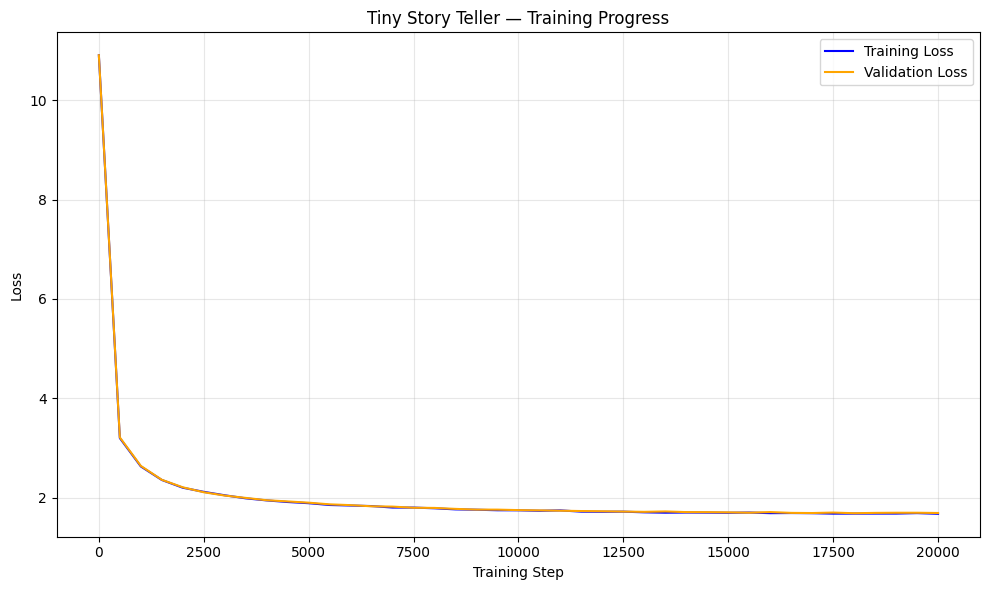

Final training loss: 1.6761
Final validation loss: 1.6922


In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
steps = [i * eval_interval for i in range(len(train_losses))]
plt.plot(steps, train_losses, label='Training Loss', color='blue')
plt.plot(steps, val_losses, label='Validation Loss', color='orange')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Tiny Story Teller — Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()

print(f"Final training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")

## Step 7: Generate Stories!
Let's see if our 15M parameter model learned to write children's stories.

In [15]:
# Load the best model
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

def generate_story(prompt, max_tokens=200, temperature=0.8):
    """Generate a story from a prompt."""
    # Tokenize the prompt
    tokens = enc.encode(prompt)
    x = torch.tensor([tokens], dtype=torch.long, device=device)

    # Generate
    with torch.no_grad():
        output = model.generate(x, max_new_tokens=max_tokens, temperature=temperature)

    # Decode back to text
    story = enc.decode(output[0].tolist())
    return story

# Test with several prompts
prompts = [
    "Once upon a time there was a",
    "A little girl went to the",
    "The dog saw a big",
    "One day, a kind old man",
    "There was a beautiful garden with",
]

for prompt in prompts:
    print(f"Prompt: '{prompt}'")
    print(f"Generated: {generate_story(prompt)}")
    print("-" * 80)
    print()

Prompt: 'Once upon a time there was a'
Generated: Once upon a time there was a small boy named Jack. He was three years old and he loved to play games. One day, Jack had an idea. He wanted to play a game with a football.

Jack said "Let's play a game!" 

Jack was very excited. He said "Yes!", and they started to play. 

Jack said "It looks like fun! Let's play a game!" 

So, Jack and Jack started to play. They had a lot of fun. In the end, the game was over! 

Jack said "I'm glad we played together."

His mom said "No problem, Jack. We can play again tomorrow. Let's go home and have a snack." 

Jack smiled. He knew that it was going to be a good day.<|endoftext|>Once upon a time, there was a little boy who liked to play. He had a toy boat and he liked to sail it around the garden. One day
--------------------------------------------------------------------------------

Prompt: 'A little girl went to the'
Generated: A little girl went to the store and saw the toy she really wanted. She 

What good output looks like:

Grammatically correct sentences (even if the story is simple)
Vocabulary appropriate for children's stories
Basic narrative structure (characters, actions, simple cause/effect)

What bad output looks like:

Random words with no grammar
Repeated tokens ("the the the the")
Completely incoherent nonsense

If you're seeing grammatically correct stories, even if they're simple or a bit repetitive, your model is working. A 15M parameter model won't write Shakespeare, but it should produce coherent children's story fragments.

Saving the model checkpoint to your local machine so we can convert it for iOS in Phase 2.

In [16]:
# Save the final model with all configuration
import json

# Save model config (we'll need this for conversion)
config = {
    'vocab_size': vocab_size,
    'n_embd': n_embd,
    'n_head': n_head,
    'n_layer': n_layer,
    'block_size': block_size,
    'dropout': dropout,
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Files to download:")
print(f"  best_model.pt ({os.path.getsize('best_model.pt') / 1e6:.1f} MB)")
print(f"  model_config.json")
print(f"  training_loss.png")

Files to download:
  best_model.pt (120.3 MB)
  model_config.json
  training_loss.png


To download from Colab:

1. Click the folder icon in the left sidebar of Colab
2. You'll see best_model.pt, model_config.json, and training_loss.png
3. Right-click each file → Download
4. Save them to your project folder: ~/Developer/tiny-story-teller/model/